# **Breast Cancer Diagnostic System**

This notebook follows a professional machine learning workflow to build a highly reliable diagnostic system.

## ***Step 1: Initial Setup***

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## ***Step 2: Data Loading***

In [112]:
df = pd.read_csv('data.csv')

## ***Step 3: Basic Data Exploration***

In [113]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [115]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## ***Step 4: Quality Assessment Check***

In [116]:
# Checking for missing values
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [117]:
# Checking for duplicate entries
df.duplicated().sum()

0

## ***Step 5: Data Cleaning***

Removing empty columns and non-essential identifiers based on discovery.

In [118]:
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True, errors='ignore')

In [119]:
# Verification
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

## ***Step 6: Target Variable Exploration***

In [120]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

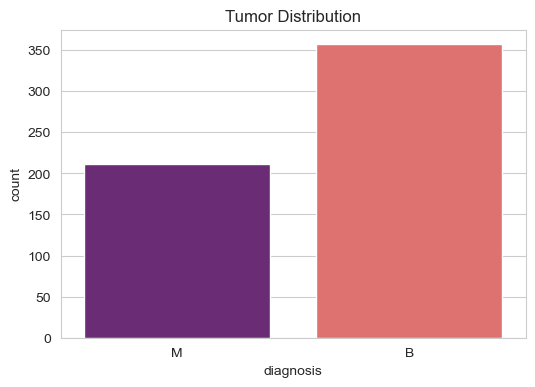

In [121]:
sns.set_style('whitegrid')
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', data=df, palette='magma')
plt.title('Tumor Distribution')
plt.show()

## ***Step 7: Preprocessing - Target Encoding***

Converting categorical labels 'M' and 'B' into numerical values 1 and 0.

In [122]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])
df['diagnosis'].head(10)

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: diagnosis, dtype: int32

## ***Step 8: Dataset Splitting (Before Scaling)***

We split the data before scaling to prevent **Data Leakage**. This ensures the test set remains truly unseen during the training process.

In [123]:
from sklearn.model_selection import train_test_split

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training size: {X_train.shape}, Testing size: {X_test.shape}')

Training size: (455, 30), Testing size: (114, 30)


## ***Step 9: Feature Scaling (Professional Approach)***

We apply `fit_transform` on the Training set to learn the mean/standard deviation, and ONLY `transform` on the Test set to use those learned parameters.

In [124]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Features scaled successfully.')

Features scaled successfully.


## ***Step 10: Observation - Feature Correlation***

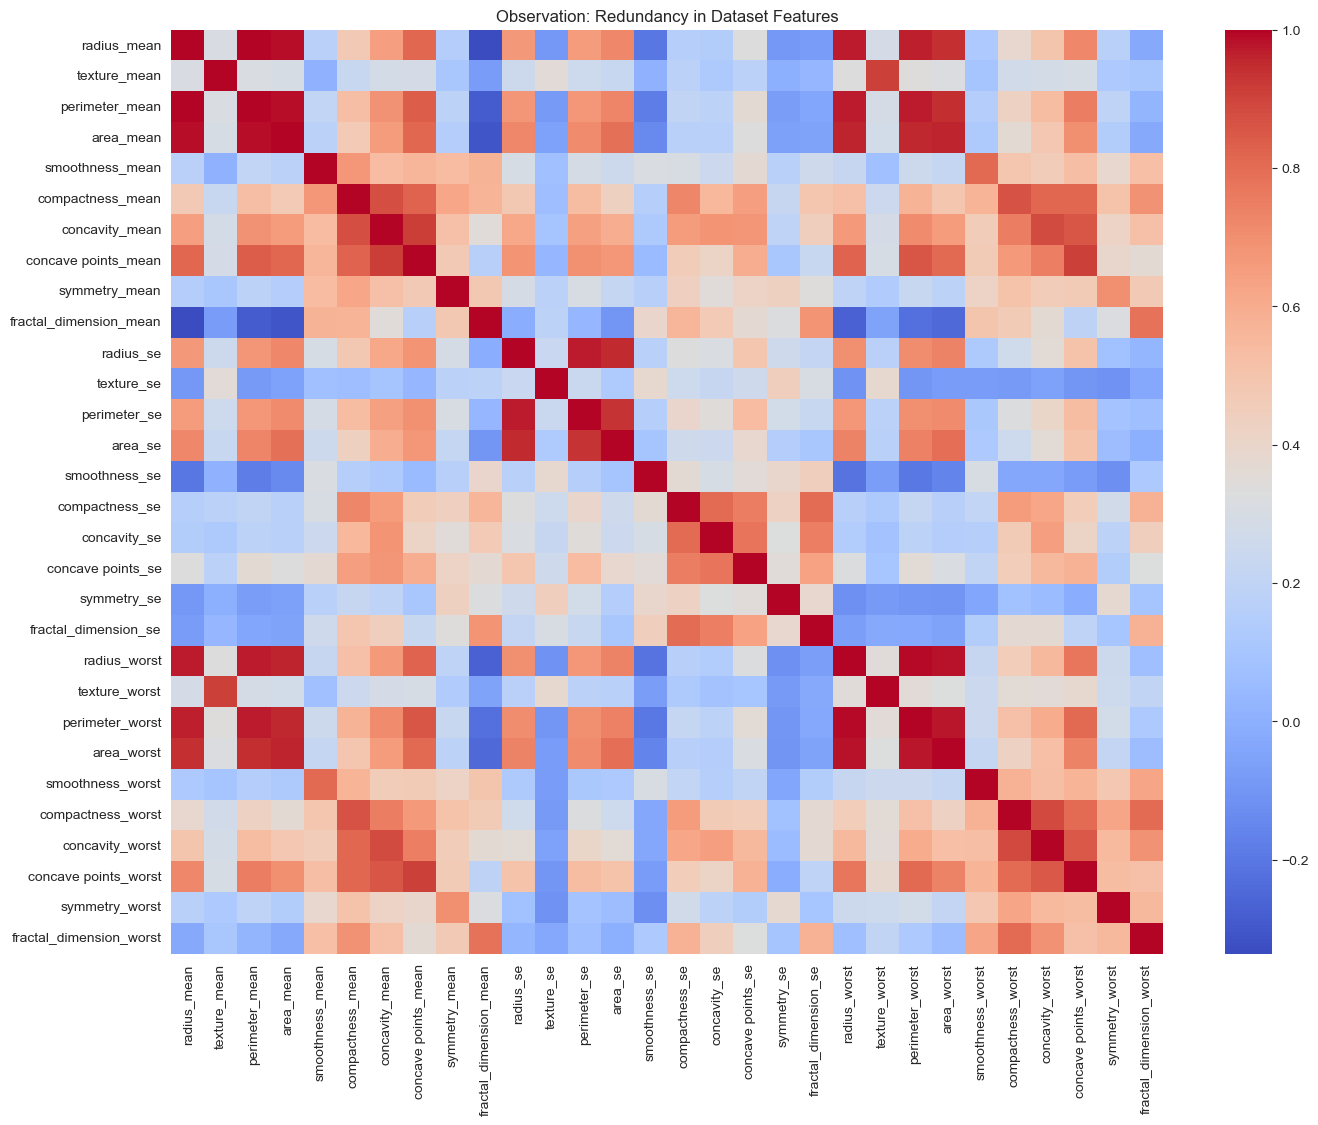

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))
# Visualizing correlations using training data only to avoid bias
correlation_matrix = pd.DataFrame(X_train_scaled, columns=X.columns).corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title('Observation: Redundancy in Dataset Features')
plt.show()

## ***Step 11: Multi-Model Comparison (Baseline - 30 Features)***

In [126]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score

models_to_test = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC()
}

baseline_list = []
for name, model in models_to_test.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    baseline_list.append({
        'Model': name,
        'Base Accuracy': accuracy_score(y_test, pred),
        'Base Recall': recall_score(y_test, pred)
    })

baseline_df = pd.DataFrame(baseline_list)
display(baseline_df)

,Model,Base Accuracy,Base Recall
0,Logistic Regression,0.973684,0.953488
1,KNN,0.947368,0.930233
2,Random Forest,0.964912,0.930233
3,SVM,0.982456,0.953488


## ***Step 12: Automatic Feature Selection (RFECV)***

### **What is RFECV?**
**RFECV (Recursive Feature Elimination with Cross-Validation)** is a robust technique to find the optimal number of features for our model.

1. **RFE (Recursive Selection):** It starts with all features, trains the model, and removes the least important features one by one.
2. **CV (Cross-Validation):** At each step, it performs cross-validation to check if the accuracy improved or dropped. 
3. **Peak Discovery:** It automatically stops at the exact number of features where the cross-validation score is at its maximum point, ensuring we don't pick too many or too few features.

In [ ]:
from sklearn.feature_selection import RFECV

# We use Random Forest as the 'Judge' model for selection
selector_agent = RFECV(estimator=RandomForestClassifier(random_state=42), step=1, cv=5, scoring='accuracy')
selector_agent.fit(X_train_scaled, y_train)

plt.figure(figsize=(10, 6))
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation Accuracy")
plt.plot(range(1, len(selector_agent.cv_results_['mean_test_score']) + 1), selector_agent.cv_results_['mean_test_score'], marker='o', color='purple')
plt.title("Discovery of Optimal Number of Features")
plt.show()

auto_features = X.columns[selector_agent.support_]
print(f'RFECV has identified {selector_agent.n_features_} optimal features.')

## ***Step 13: Multi-Model Comparison (Optimized Features)***

In [ ]:
X_train_final = selector_agent.transform(X_train_scaled)
X_test_final = selector_agent.transform(X_test_scaled)

opt_list = []
final_trained_models = {}

for name, model_obj in models_to_test.items():
    new_model = model_obj
    new_model.fit(X_train_final, y_train)
    pred = new_model.predict(X_test_final)
    final_trained_models[name] = new_model
    opt_list.append({
        'Model': name,
        'Opt Accuracy': accuracy_score(y_test, pred),
        'Opt Recall': recall_score(y_test, pred)
    })

optimized_df = pd.DataFrame(opt_list)
master_report = pd.merge(baseline_df, optimized_df, on='Model')
for col in ['Base Accuracy', 'Base Recall', 'Opt Accuracy', 'Opt Recall']:
    master_report[col] = (master_report[col] * 100).round(2)
display(master_report)

## ***Step 14: Final Verdict & Exporting the Honest Champion***

In [ ]:
import joblib
winner_data = optimized_df.sort_values(by=['Opt Recall', 'Opt Accuracy'], ascending=False).iloc[0]
winner_name = winner_data['Model']
final_champion = final_trained_models[winner_name]

print(f'THE SCIENTIFIC CHAMPION IS: {winner_name}')

joblib.dump(final_champion, 'final_medical_model.pkl')
joblib.dump(auto_features, 'best_features.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('[SUCCESS] Professional Unbiased Model Saved!')

THE SCIENTIFIC CHAMPION IS: Logistic Regression
[SUCCESS] Professional Unbiased Model Saved!


## ***Step 15: Testing the Exported Files (Inference Test)***

Now we will load our saved files and simulate a prediction for a new patient.

In [ ]:
import joblib
import numpy as np

# 1. Loading the Brain, the Filter, and the Translator
loaded_model = joblib.load('final_medical_model.pkl')
loaded_features = joblib.load('best_features.pkl')
loaded_scaler = joblib.load('scaler.pkl')


FileNotFoundError: [Errno 2] No such file or directory: 'final_medical_model.pkl'

In [ ]:
# 2. Simulating new patient data (taking one row from original data for testing)
# Imagine this data is coming from a Web Form
patient_raw_data = X.iloc[10:11] # Taking the 10th patient as an example

# 3. Preprocessing the input
scaled_data = loaded_scaler.transform(patient_raw_data)

# Creating a DataFrame for the scaled data to easily filter by feature names
scaled_df = pd.DataFrame(scaled_data, columns=X.columns)

# Extracting only the BEST features that the model understands
final_input = scaled_df[loaded_features]

# 4. Making the Prediction
prediction = loaded_model.predict(final_input)
confidence = loaded_model.predict_proba(final_input)

print('--- DIAGNOSIS RESULT ---')
if prediction[0] == 1:
    print('Status: MALIGNANT (Cancer Detected)')
else:
    print('Status: BENIGN (No Cancer)')

print(f'Confidence Score: {np.max(confidence)*100:.2f}%')

NameError: name 'loaded_scaler' is not defined